In [1]:
# utils
import sys
import logging
import time
import pickle
import numpy as np
import pandas as pd
import pickle as pkl
from pathlib import Path
from tqdm import tqdm

#sk 
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold

#plot
import matplotlib.pyplot as plt


##### Technical procedure:
- get cell states (predictors) and matching temp timeseries (target) (matching regarding the 365 warmup and also the inherent availability of discharge data maybe use dates)
- split into train- and test-set and train, return R² and RMSE 

_notes:_
- _don't return dataset, but return model and metadata (train period, test period, metrics)_

In [2]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
    cell_states = pickle.load(f)

In [3]:
with open("/home/wuhlmann/BA/data/processed_data/eda/normal_periods.pkl", "rb") as f: 
    discharge_coverage = pickle.load(f)

In [4]:
basin_id = 410

In [5]:
ts_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily")

ts_116 = pd.read_table(ts_path / f"ID_{basin_id}.csv", header=0, sep=";")

ts_116["date"] = pd.to_datetime(
            ts_116[["YYYY", "MM", "DD"]].rename(columns={"YYYY": "year", "MM": "month", "DD": "day"})
        )
ts_116.set_index("date", inplace=True)

# drop all columns except for 2m_mean_temp
ts_116 = ts_116[["2m_temp_mean"]]


In [6]:
from sklearn.preprocessing import StandardScaler

c_116 = StandardScaler().fit_transform(cell_states[str(basin_id)]["c_last"])

In [7]:
dataset = np.c_[c_116, ts_116["2m_temp_mean"].values[-(len(c_116)):]]

R2 of 0.93 | MAE of 1.5330757616266681
R2 of 0.92 | MAE of 1.6242653937355622
R2 of 0.92 | MAE of 1.672967888427166
R2 of 0.92 | MAE of 1.6499448937812182
R2 of 0.93 | MAE of 1.5169649500105216
R2 of 0.95 | MAE of 1.3099731235492746
R2 of 0.95 | MAE of 1.2730859790083604
R2 of 0.94 | MAE of 1.4637293512917178
R2 of 0.95 | MAE of 1.3496963850314778
R2 of 0.95 | MAE of 1.3208899663271
R2 of 0.94 | MAE of 1.6109432887808592
R2 of 0.91 | MAE of 1.6481299585577105
R2 of 0.88 | MAE of 2.0547769485149447
R2 of 0.91 | MAE of 1.8662861863175677
R2 of 0.93 | MAE of 1.6752752852743693
R2 of 0.73 | MAE of 1.6823210827889499
R2 of 0.87 | MAE of 1.3322734701831884
R2 of 0.85 | MAE of 1.7538571618888141
R2 of 0.48 | MAE of 2.4839104658362285
R2 of 0.85 | MAE of 1.5559314007335232


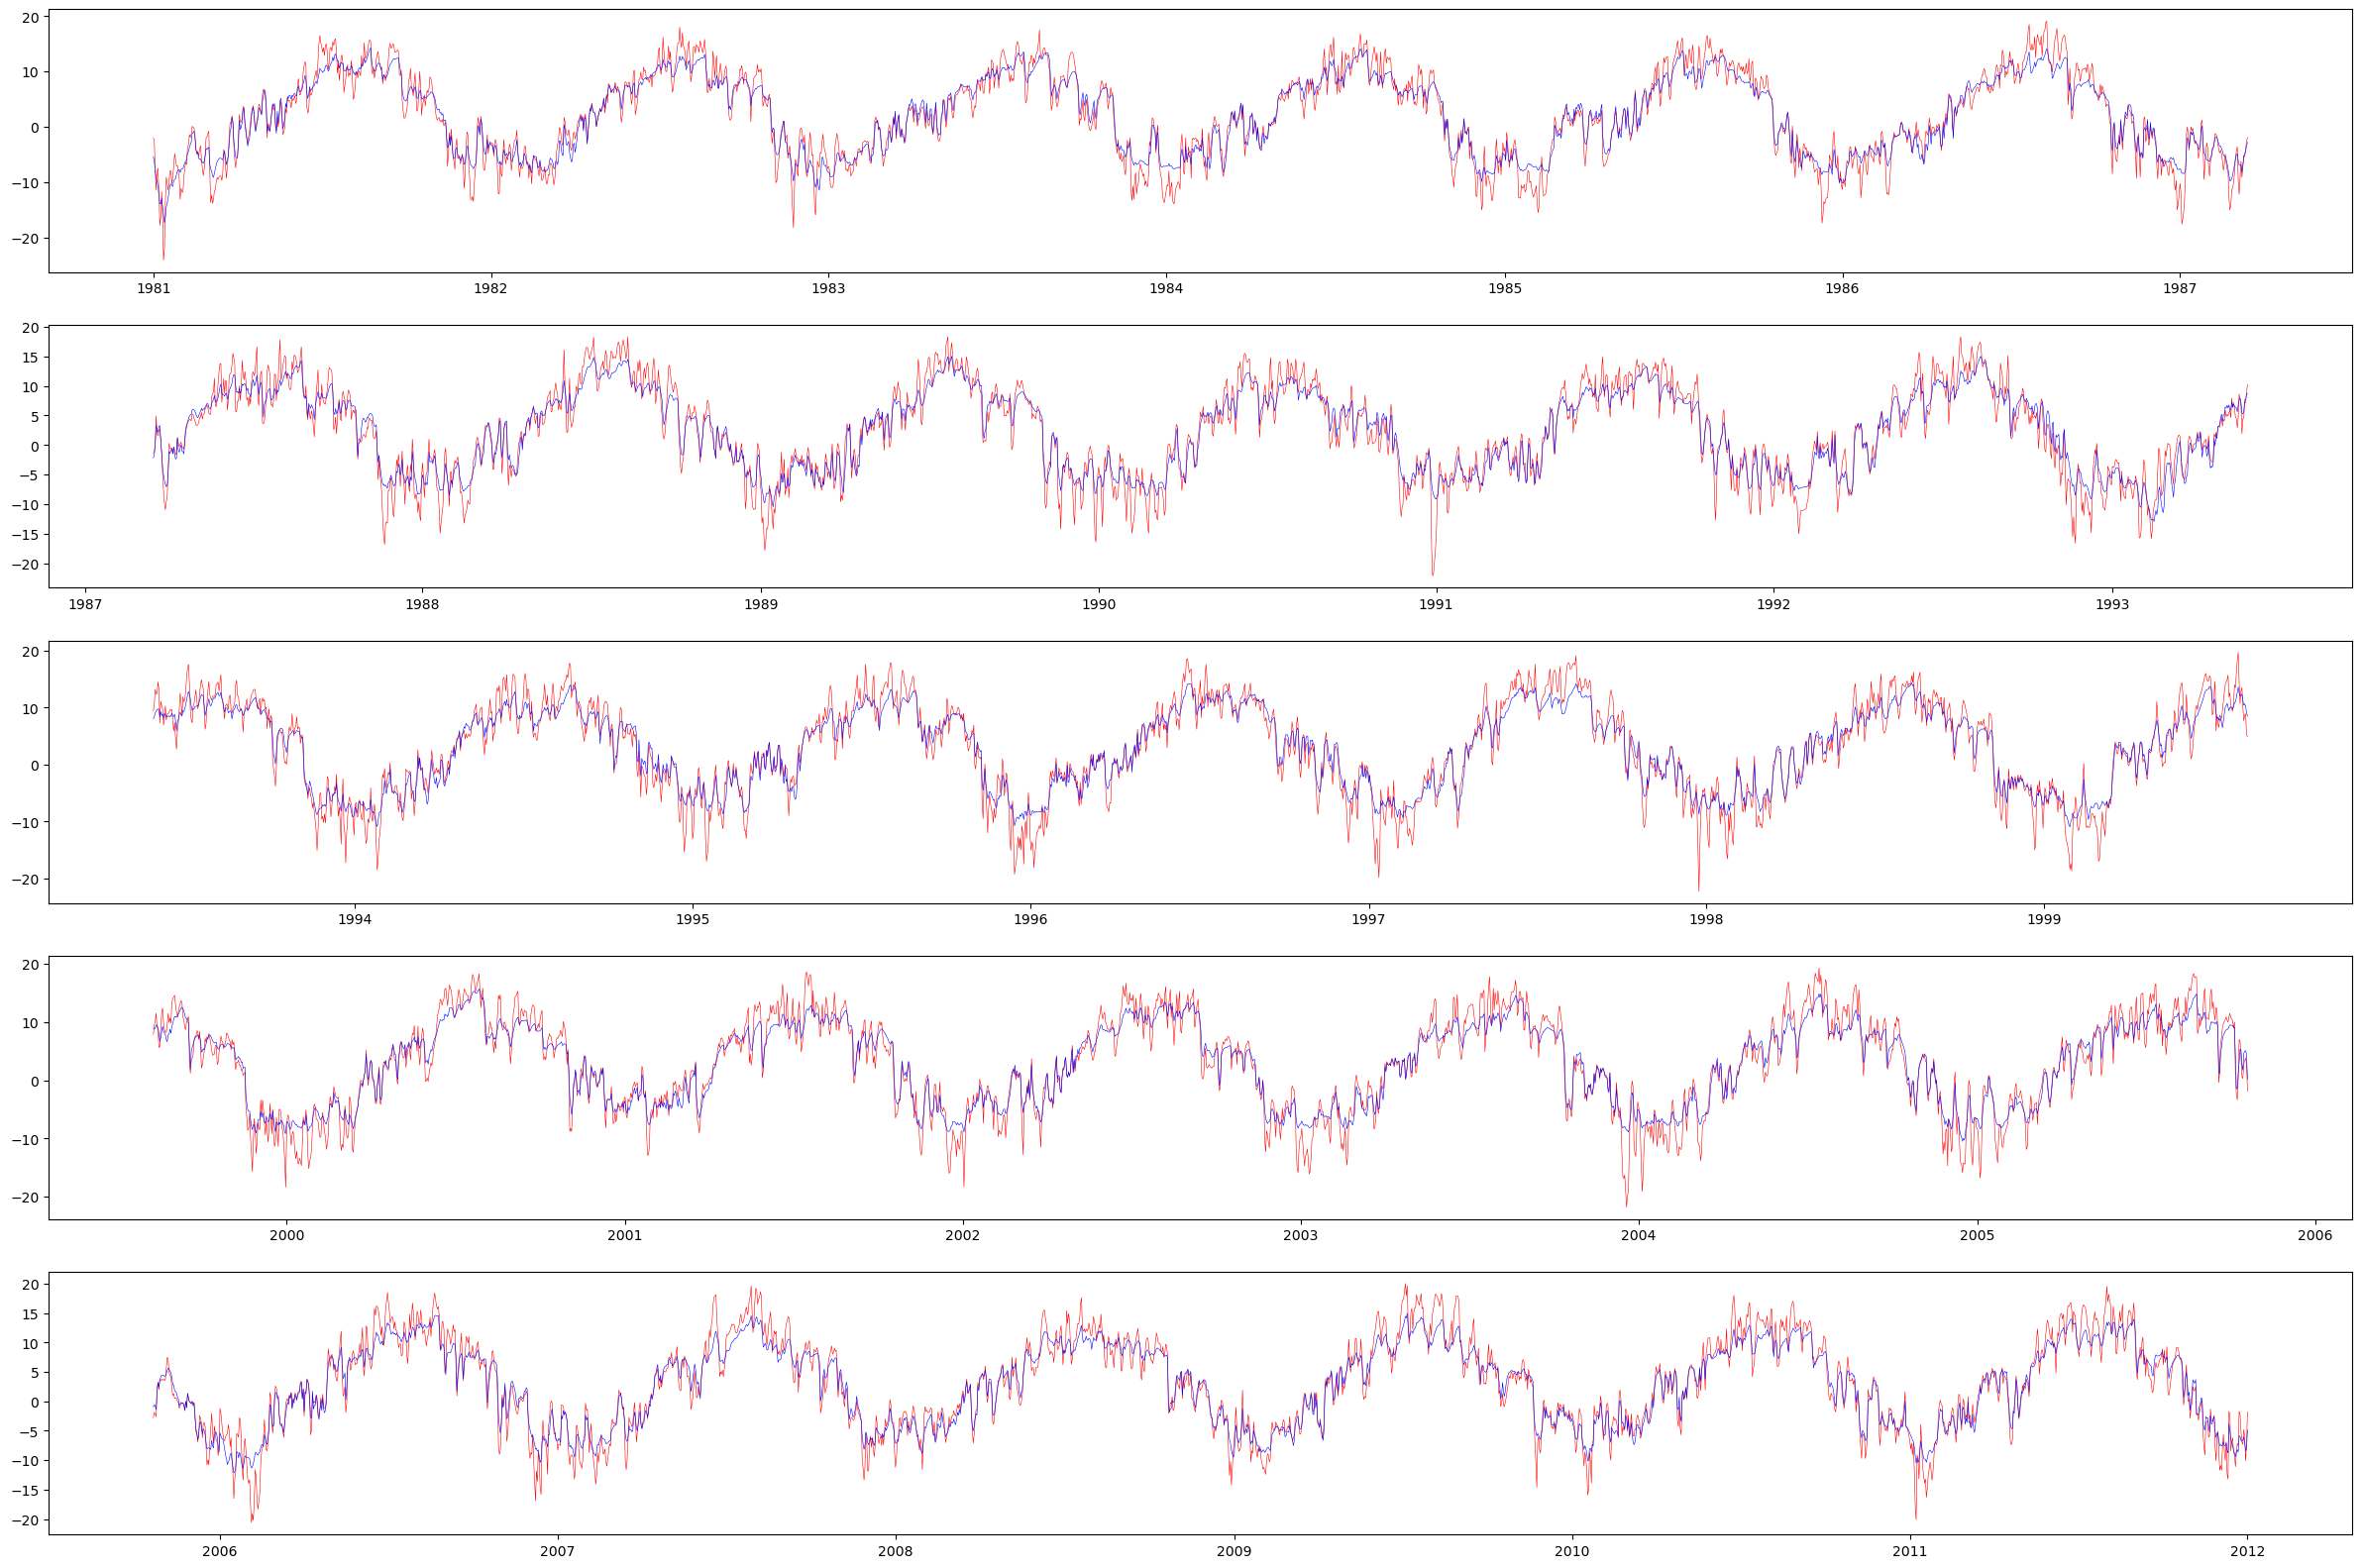

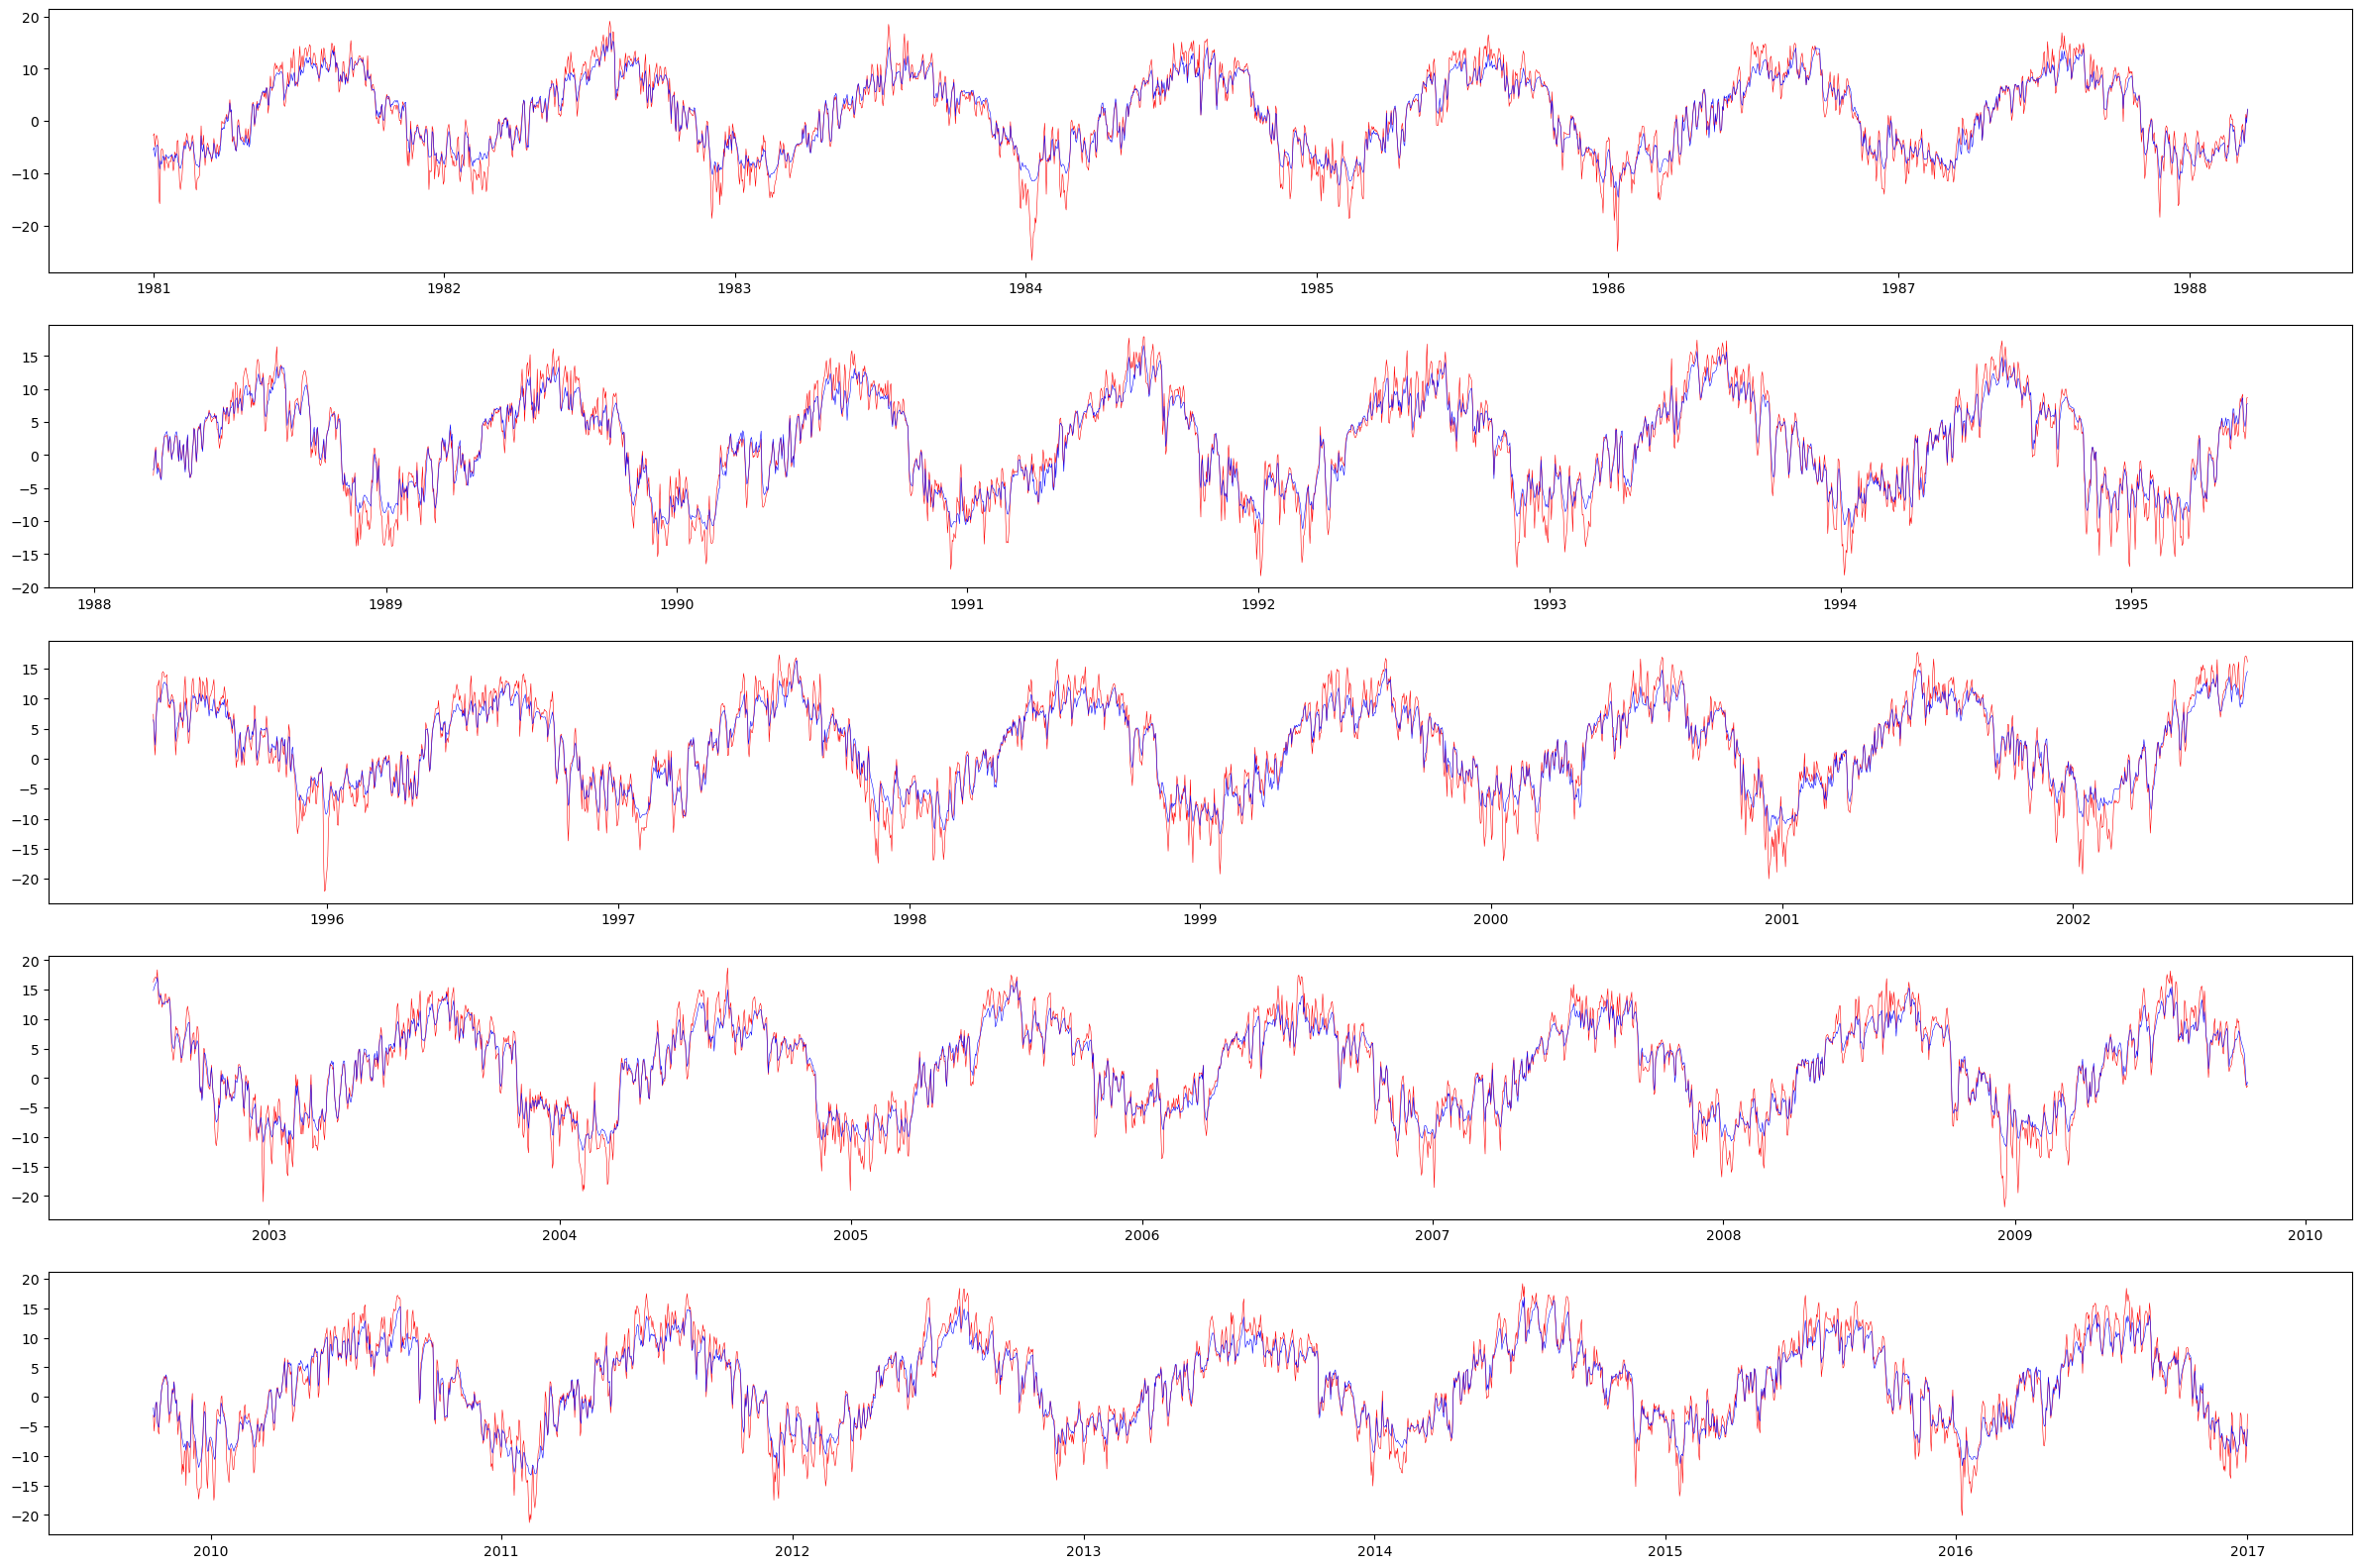

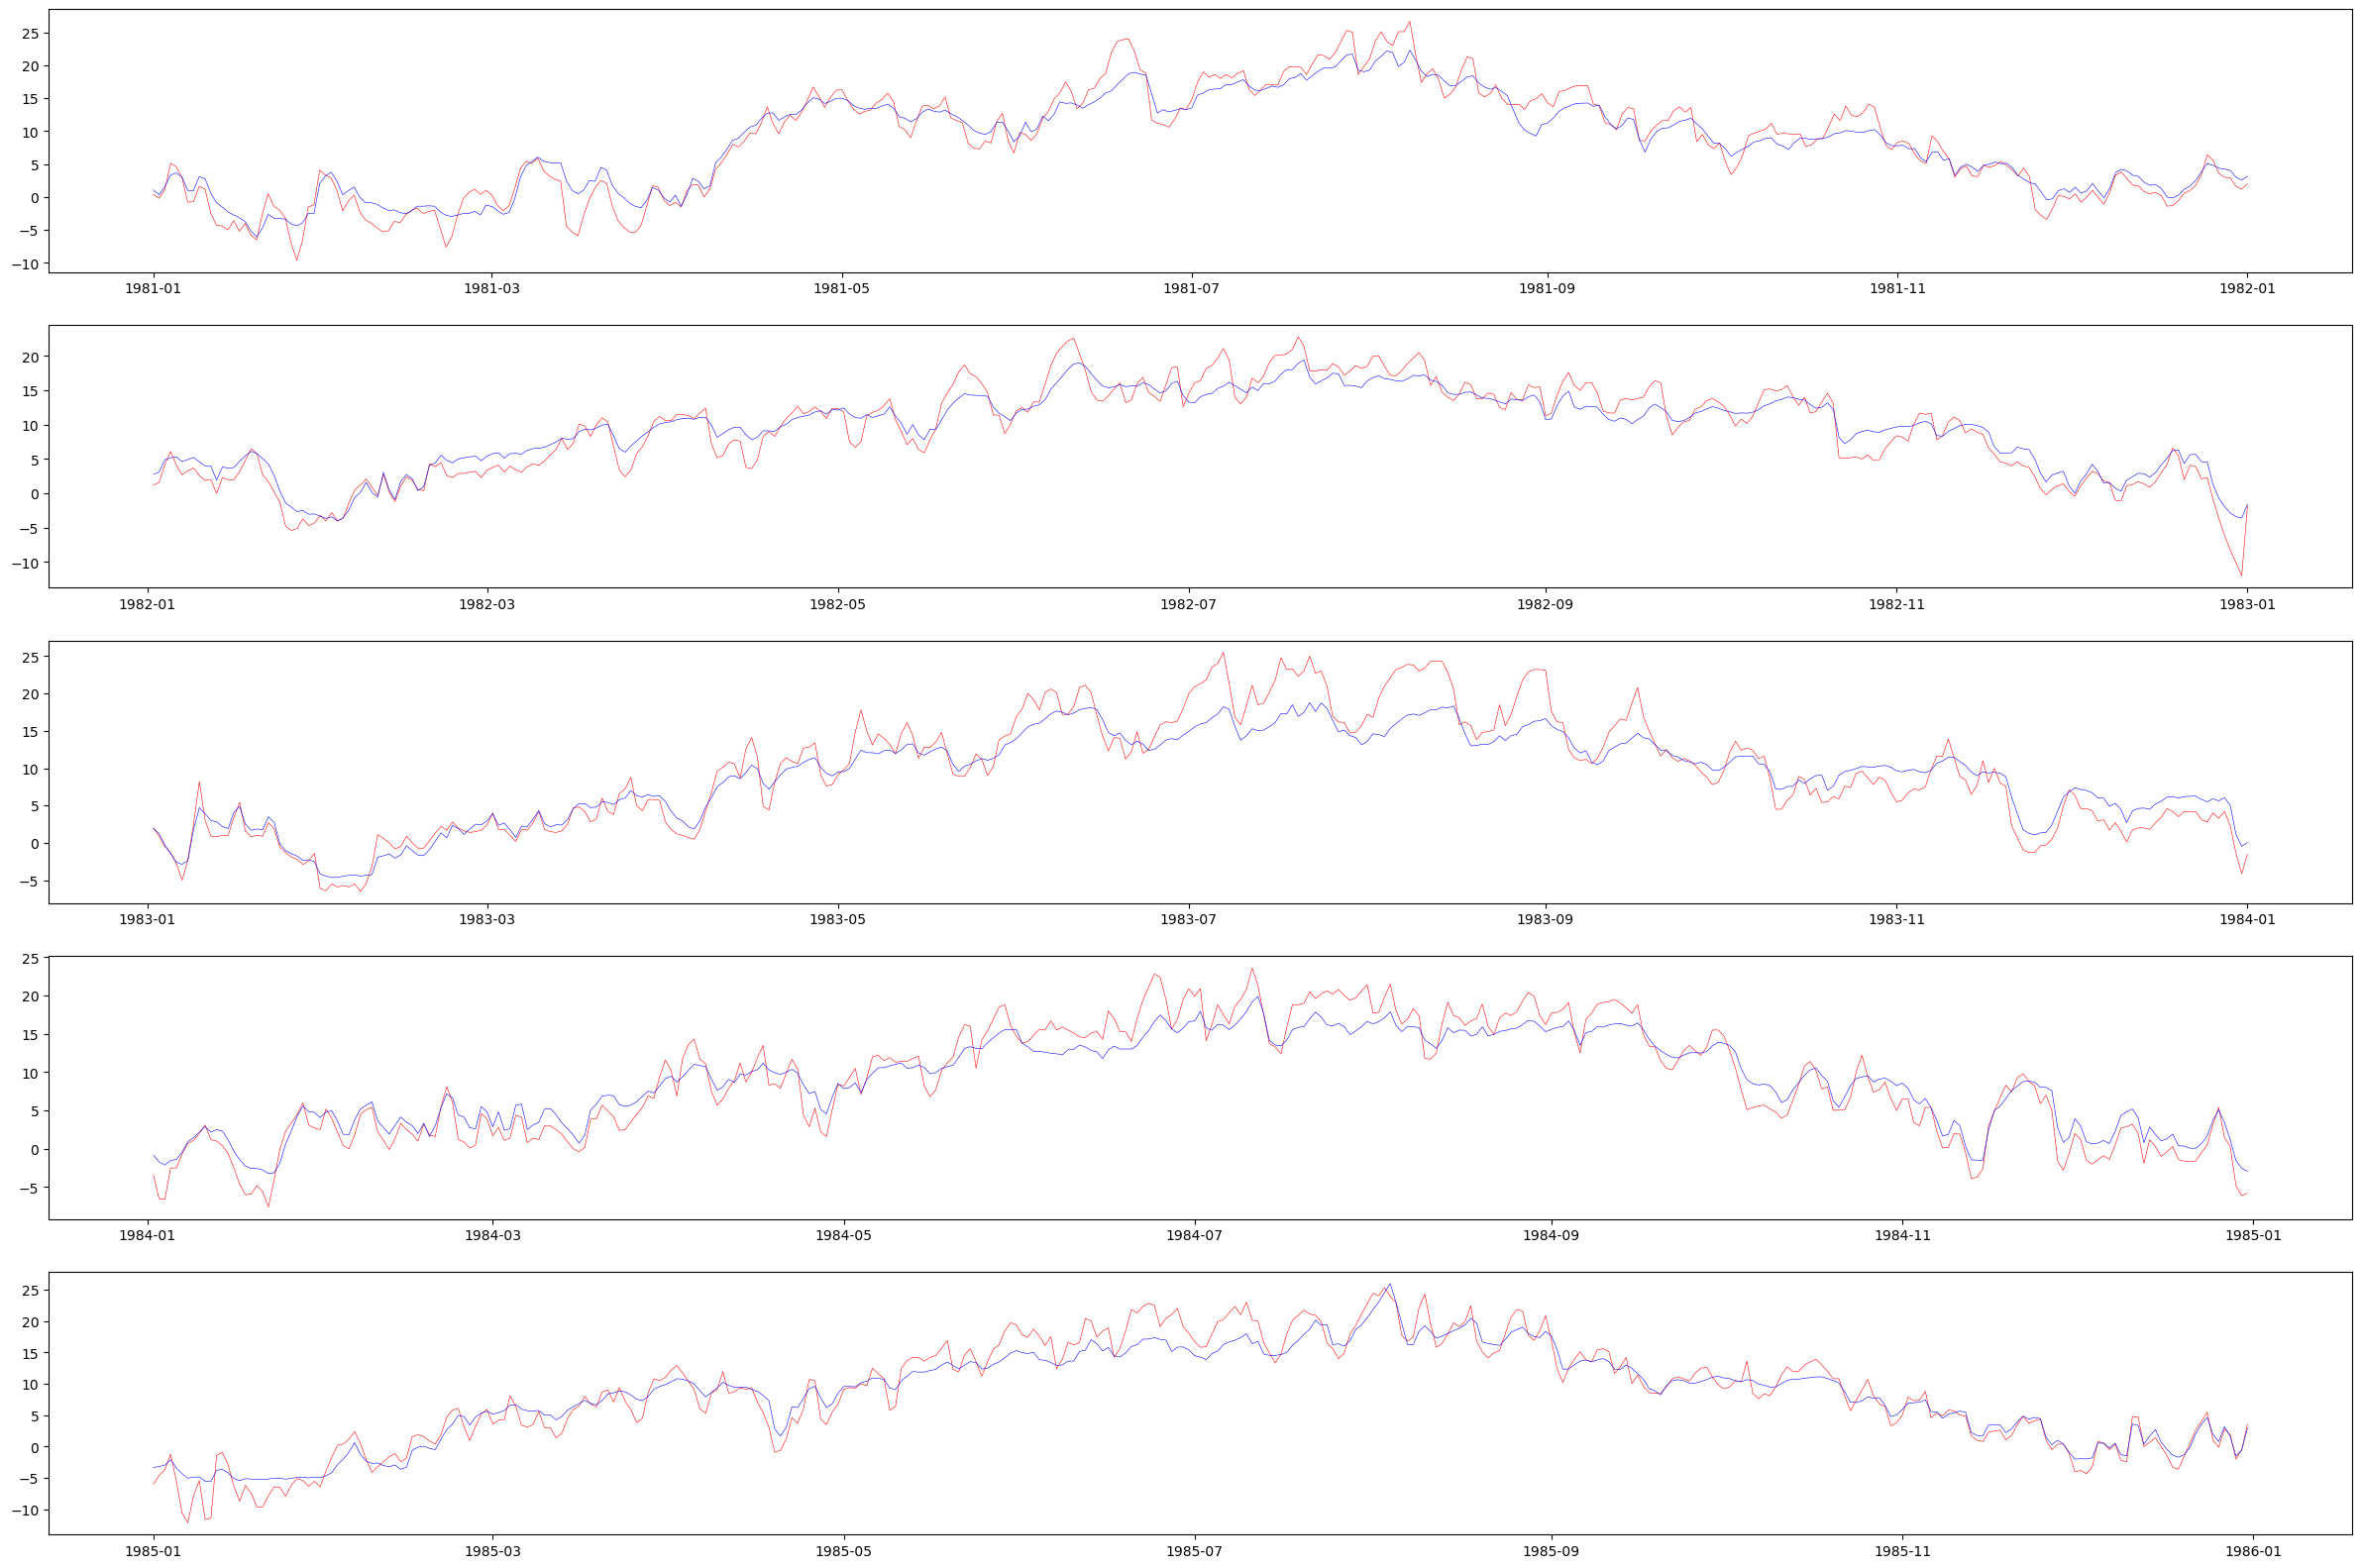

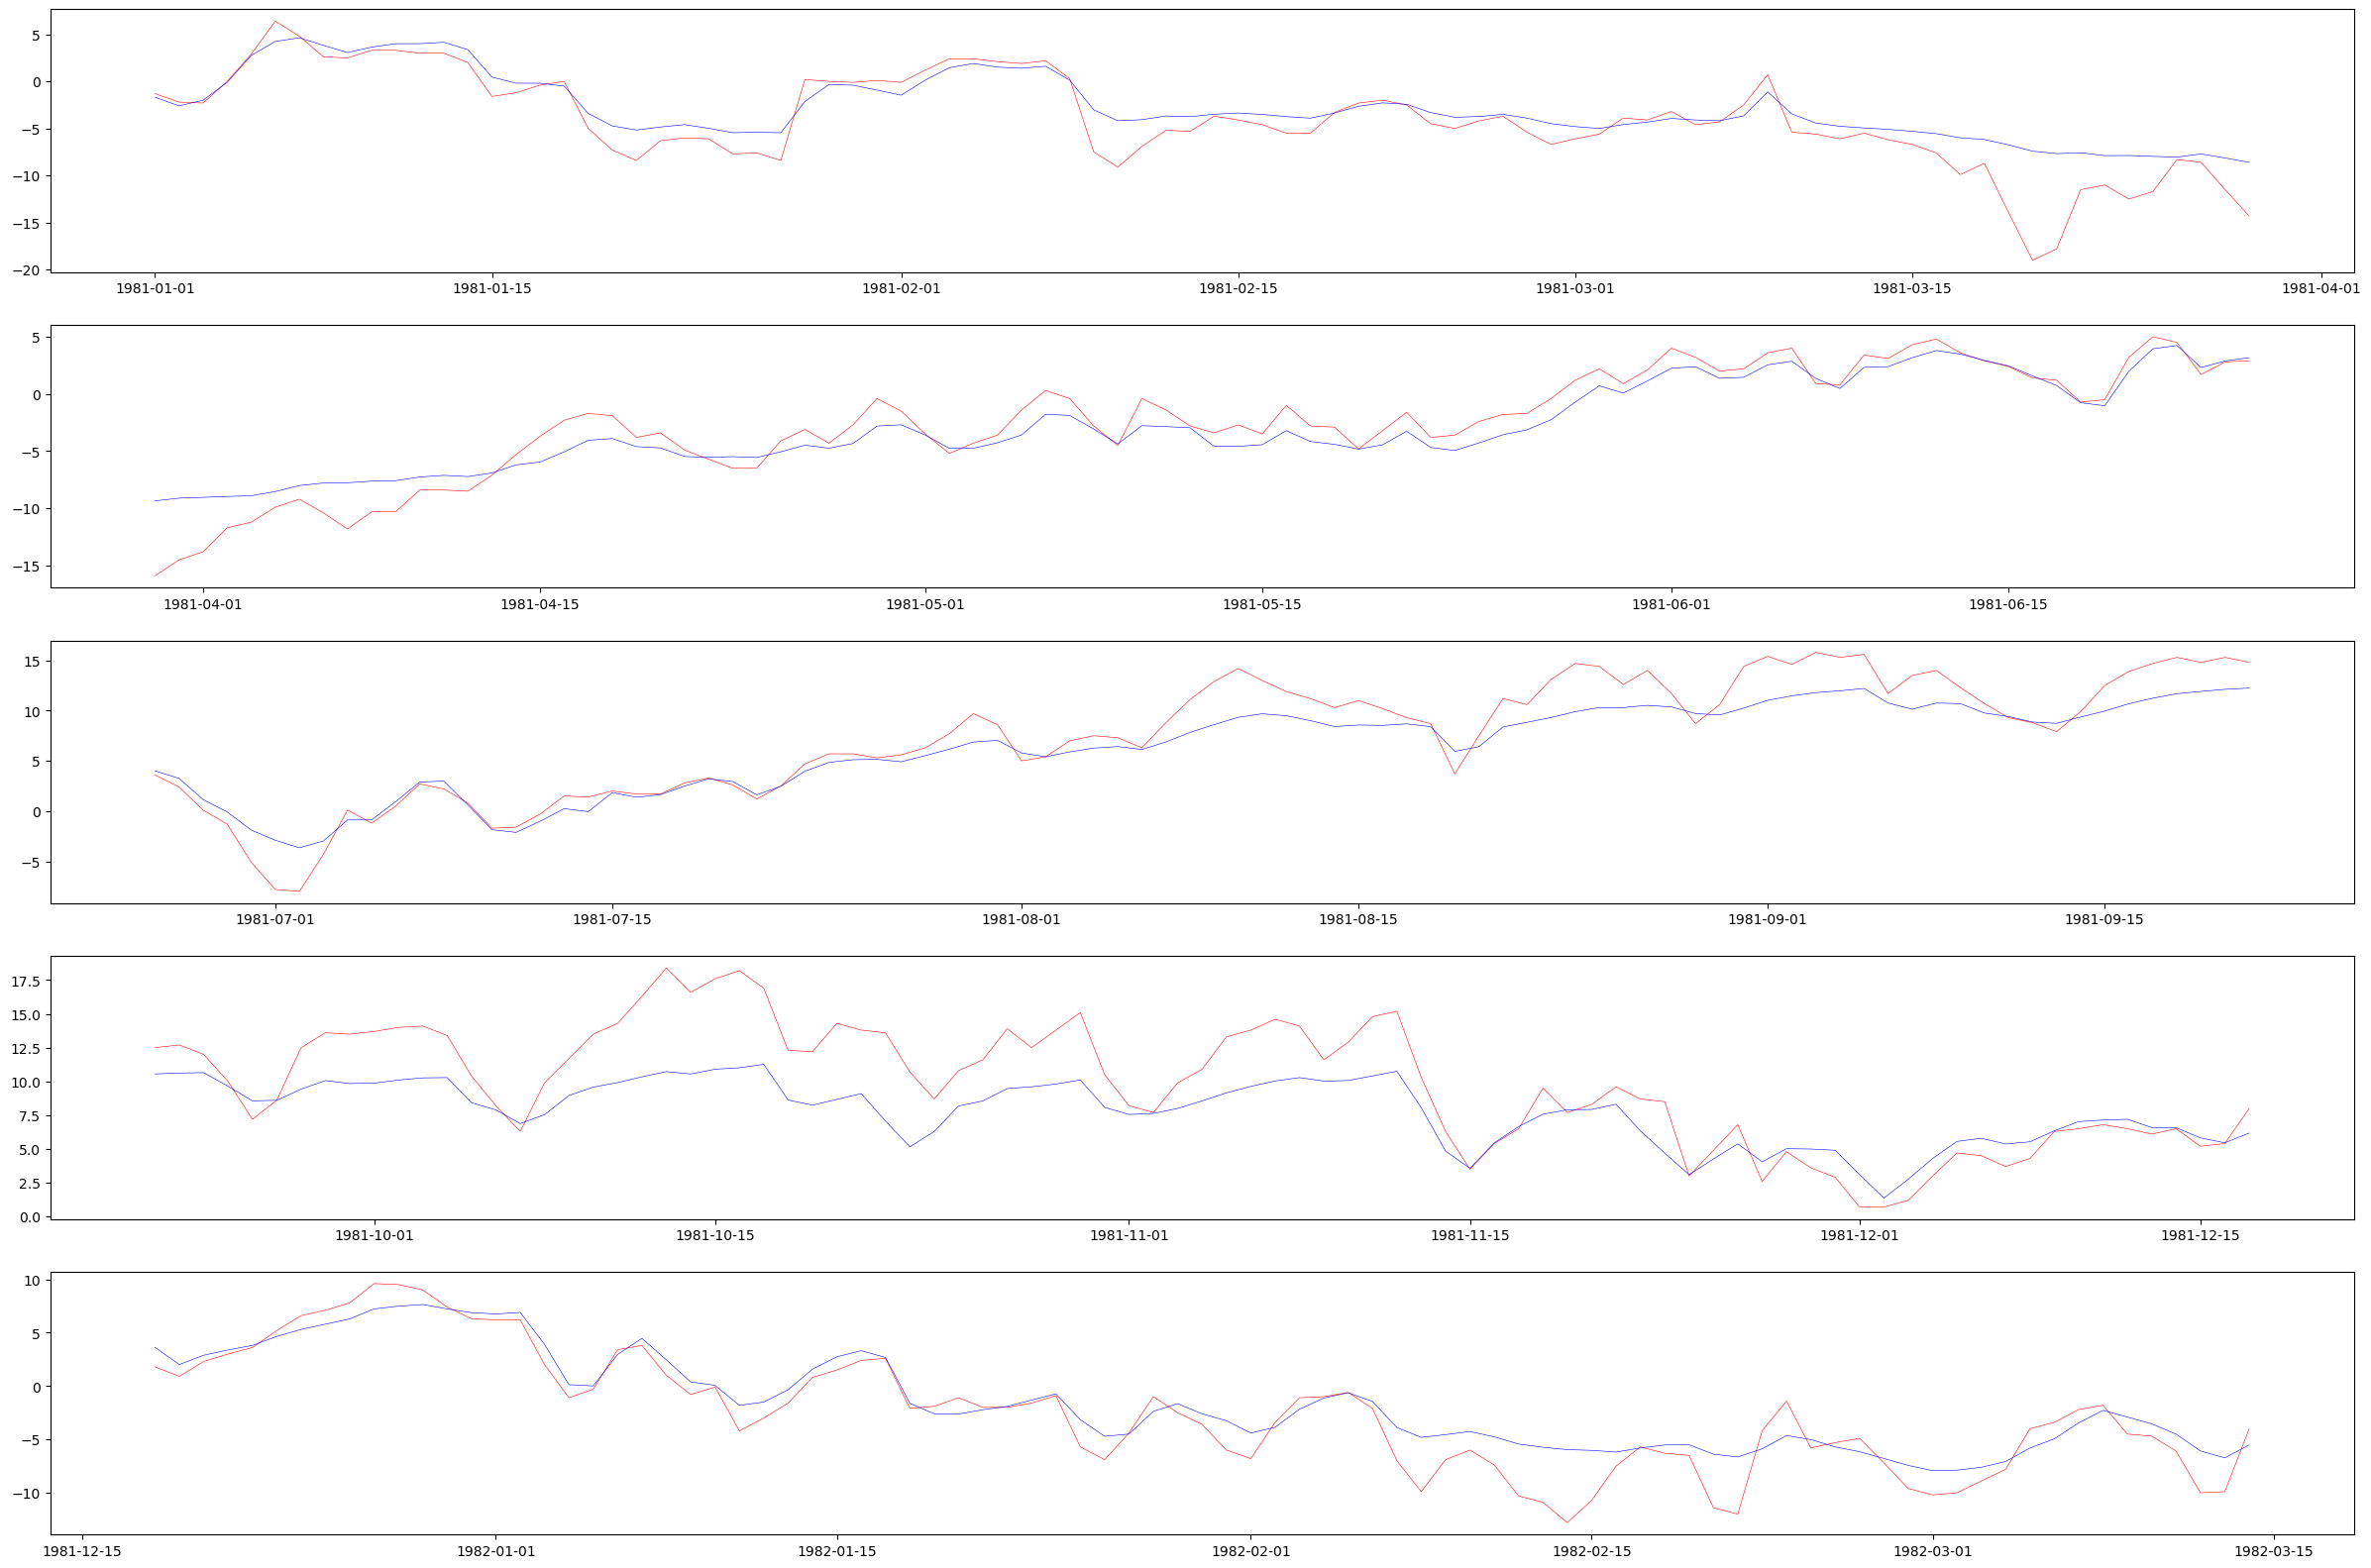

In [8]:
ts_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily")
model_coef = []

for basin_id in [116,117,410,553]: 

	ts = pd.read_table(ts_path / f"ID_{basin_id}.csv", header=0, sep=";")

	ts["date"] = pd.to_datetime(
				ts[["YYYY", "MM", "DD"]].rename(columns={"YYYY": "year", "MM": "month", "DD": "day"})
			)
	ts.set_index("date", inplace=True)

	# drop all columns except for 2m_mean_temp
	ts = ts[["2m_temp_mean"]]

	ts  = ts[discharge_coverage.loc[basin_id,"start_date"]:discharge_coverage.loc[basin_id, "end_date"]]
	c = StandardScaler().fit_transform(cell_states[str(basin_id)]["c_last"])
	dataset = np.c_[c, ts["2m_temp_mean"].values[-(len(c)):]]

	model = ElasticNet()
	kfold = KFold(n_splits=5)
	folds = list(kfold.split(dataset[:,:-1], dataset[:,-1]))

	fig, axs = plt.subplots(5,1, figsize=(30,20))

	best_r2 = -100
	best_model_id = None
	coef_list = []

	for i, f, ax in zip([0,1,2,3,4],folds, axs):
		
		train_ids = f[0]
		test_ids = f[1]

		target = dataset[:,-1][test_ids]

		model.fit(X=dataset[:,:-1][train_ids], y=dataset[:,-1][train_ids])
		pred = model.predict(X=dataset[:,:-1][test_ids])

		coef_list.append(model.coef_)

		r2 = r2_score(target, pred)

		if r2 > best_r2: 
			best_r2 = r2
			best_model_id = i

		print(f"R2 of {r2:.2f} | MAE of {mean_absolute_error(target, pred)}")

		ax.plot(ts_116.index[test_ids], target, color="red", linewidth=0.4)
		ax.plot(ts_116.index[test_ids], pred, color="blue", linewidth=0.4)

	model_coef.append(coef_list[best_model_id])


In [9]:
model_coef = StandardScaler().fit_transform(model_coef)

<Axes: >

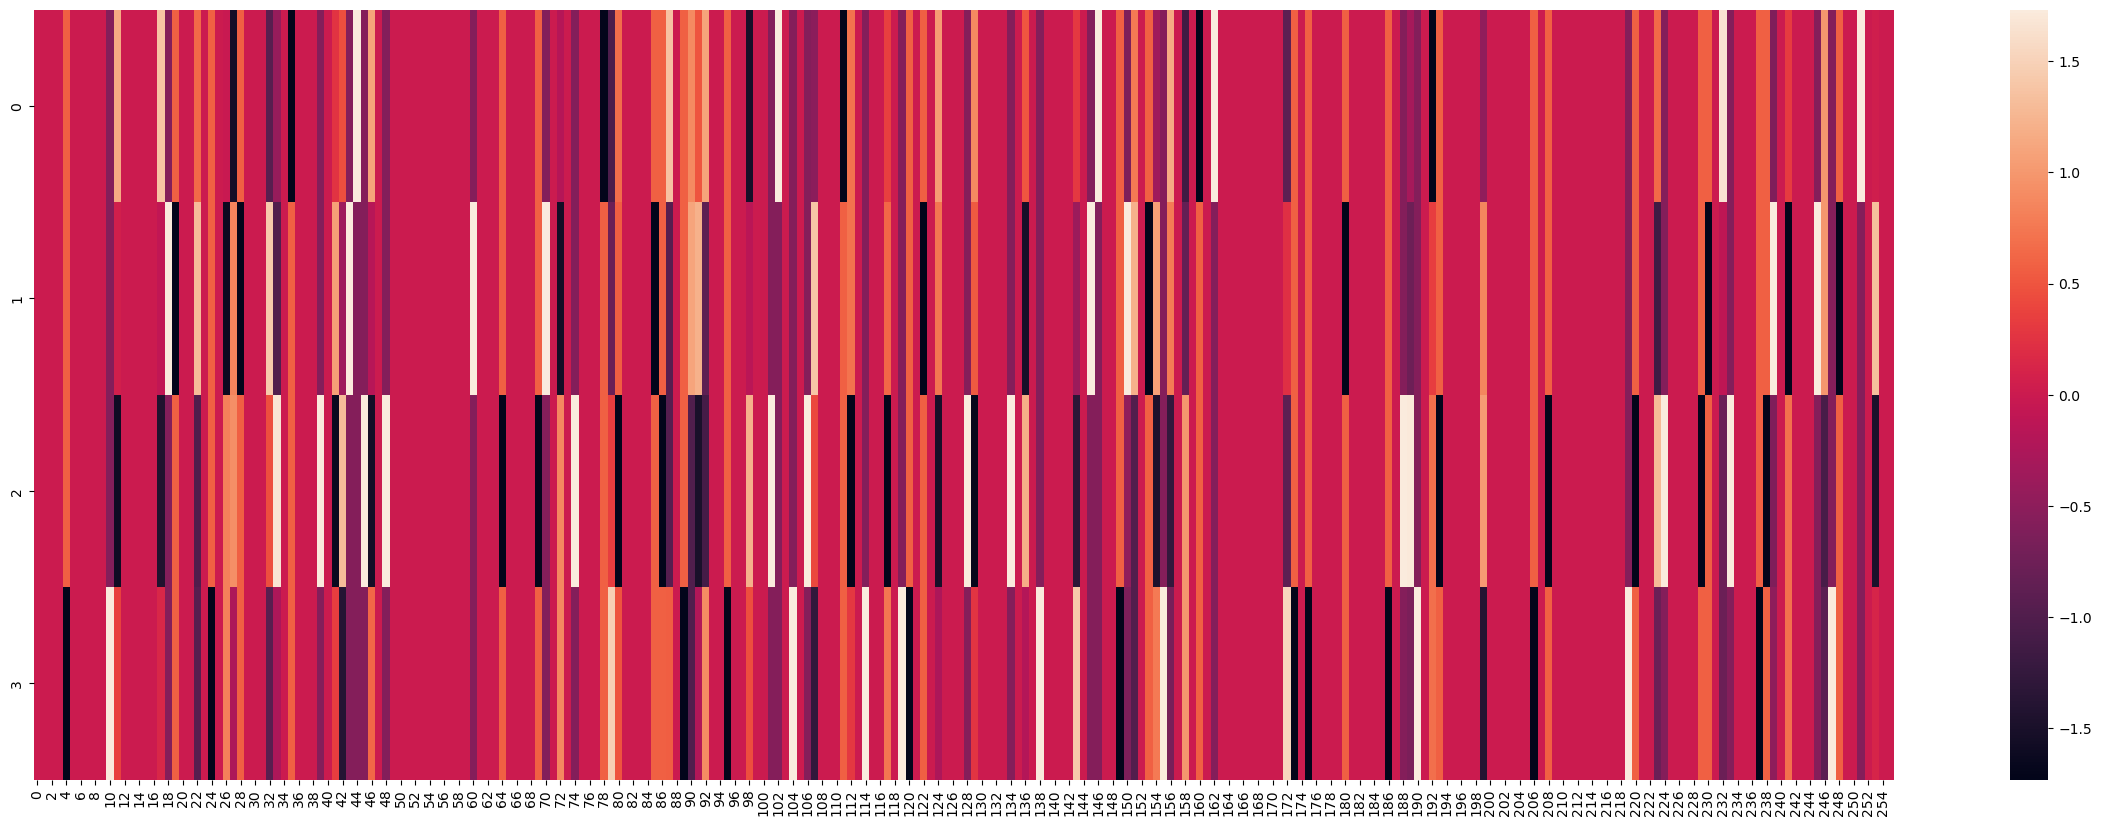

In [10]:
import seaborn as sns

fig = plt.figure(figsize=(30,10))
ax = fig.add_subplot(111)
sns.heatmap(np.vstack(list(map(lambda x: x.reshape(1,256), model_coef))), ax=ax)

we use c of day of prediction, since it most acuratly represents the condition of the day the model predicts

In [11]:
for coef in model_coef: 
    
	print(sorted((-coef).argsort()[:5]))

[44, 102, 146, 162, 251]
[18, 43, 60, 70, 145]
[39, 48, 101, 106, 128]
[104, 119, 138, 155, 219]
